In [1]:
import os
import ast
import numpy as np
import pandas as pd
from tqdm import tqdm
import scipy

import cv2
from skimage.measure import regionprops, label, shannon_entropy
from skimage.transform import resize
from skimage.color import rgb2gray
from skimage import img_as_ubyte
from brisque import BRISQUE
from skvideo.measure import niqe
from pypiqe import piqe
from mahotas.features import zernike_moments
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import torch
from torch.utils.data import Subset, Dataset, DataLoader
from torchvision import datasets, transforms
import segmentation_models_pytorch as smp

# Patch imresize if missing
if not hasattr(scipy.misc, "imresize"):
    def imresize(arr, size, interp=None, mode=None):
        if isinstance(size, float):  # scale factor
            new_shape = (int(arr.shape[0] * size), int(arr.shape[1] * size))
        else:
            new_shape = size[:2]
        arr_resized = resize(arr, new_shape, order=3, mode="reflect", anti_aliasing=True)
        arr_resized = (arr_resized * 255).astype(np.uint8)
        return arr_resized
    scipy.misc.imresize = imresize

# Patch for deprecated NumPy aliases (for backward compatibility)
if not hasattr(np, 'int'):
    np.int = int
if not hasattr(np, 'float'):
    np.float = float
if not hasattr(np, 'bool'):
    np.bool = bool

In [2]:
DATA_DIR = r'/home/c/choton/beemachine/datasets/Others/fish-vista'
MODEL_NAME = "deeplabv3plus" # Available options are: ['unet', 'unetplusplus', 'manet', 'linknet', 'fpn', 'pspnet', 'deeplabv3', 'deeplabv3plus', 'pan', 'upernet', 'segformer', 'dpt']"
ENCODER_NAME = "resnext50_32x4d"
MODEL_WEIGHTS = r"/home/c/choton/beemachine/codes/AG_vision_2026/2_segmentation/FishVista/deeplabv3plus/lightning_logs/version_3/checkpoints/epoch=199-step=40600.ckpt"
DEVICE_ID = 0
EPOCHS = 200
LEARNING_RATE = 1e-4
BATCH_SIZE = 128
IMAGE_SIZE = 320
SEED = 42

# Load the classification splits and check the shape
train_csv = os.path.join(DATA_DIR, r'classification_train.csv')
val_csv = os.path.join(DATA_DIR, r'classification_val.csv')
test_csv = os.path.join(DATA_DIR, r'classification_test.csv')
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

classes = sorted(train_df['standardized_species'].unique())
num_classes = len(classes)
class_to_idx = {cls: i for i, cls in enumerate(classes)}
print(f'Shape of FishVista classification datasets,  train: {train_df.shape}, validation: {val_df.shape}, test): {test_df.shape}')
print(f'Columns of the test dataset:', list(test_df.columns))

# Load the segmentation splits and check the shape
seg_train_csv = os.path.join(DATA_DIR, r'segmentation_train.csv')
seg_val_csv = os.path.join(DATA_DIR, r'segmentation_val.csv')
seg_test_csv = os.path.join(DATA_DIR, r'segmentation_test.csv')
seg_train_df = pd.read_csv(seg_train_csv)
seg_val_df = pd.read_csv(seg_val_csv)
seg_test_df = pd.read_csv(seg_test_csv)
print(f'Shape of FishVista segmentation datasets,  train: {seg_train_df.shape}, validation: {seg_val_df.shape}, test): {seg_test_df.shape}')
print(f'Columns of the test dataset:', list(seg_test_df.columns))

# Class labels of the segmentation split
train_species = set(list(seg_train_df['standardized_species']))
val_species = set(list(seg_val_df['standardized_species']))
test_species = set(list(seg_test_df['standardized_species']))
check_val = [v for v in val_species if v not in train_species]
check_test = [v for v in test_species if v not in train_species]
print(f'The number of classes (species) are, train: {len(train_species)}, val: {len(val_species)}, test: {len(test_species)}')
print(f'Species in val but not train: {len(check_val)},  species in test but not train: {len(check_test)}')

# Read the mask labels (traits)
seg_json_path = os.path.join(DATA_DIR, 'segmentation_masks', 'seg_id_trait_map.json')
with open(seg_json_path, 'r') as json_file:
    content = json_file.read()
    seg_json = ast.literal_eval(content)
    print('Names of the mask labels (traits):')
    print(seg_json)
labels = list(seg_json.values())

/tmp/ipykernel_1403146/2035820690.py:16: DtypeWarning: Columns (15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(train_csv)


Shape of FishVista classification datasets,  train: (39800, 17), validation: (6779, 17), test): (9781, 17)
Columns of the test dataset: ['filename', 'source_filename', 'original_format', 'arkid', 'family', 'source', 'owner', 'standardized_species', 'original_url', 'license', 'adipose_fin', 'pelvic_fin', 'barbel', 'multiple_dorsal_fin', 'file_name', 'verbatim_species', 'species']
Shape of FishVista segmentation datasets,  train: (4312, 11), validation: (316, 11), test): (1504, 11)
Columns of the test dataset: ['index', 'filename', 'source_filename', 'original_format', 'arkid', 'source', 'owner', 'license', 'original_url', 'family', 'standardized_species']
The number of classes (species) are, train: 2586, val: 303, test: 1224
Species in val but not train: 146,  species in test but not train: 639
Names of the mask labels (traits):
{0: 'Background', 1: 'Head', 2: 'Eye', 3: 'Dorsal fin', 4: 'Pectoral fin', 5: 'Pelvic fin', 6: 'Anal fin', 7: 'Caudal fin', 8: 'Adipose fin', 9: 'Barbel'}


In [3]:
# Create SIFT and ORB detectors once
sift = cv2.SIFT_create()
orb = cv2.ORB_create()
bri_obj = BRISQUE(url=False)

def extract_base_features(mask):
    """Compute geometric, Zernike, Fourier, and texture shape descriptors from a binary mask."""
    
    features = ["area", "perimeter", "aspect_ratio", "extent", "solidity", "eccentricity", 
        "orientation", "circularity", "elongation", "compactness"]
    
    if mask is None or mask.sum() == 0:
        return {f: 0 for f in features}

    # --- Region properties ---
    # mask = mask.astype(np.uint8)
    labeled = label(mask)
    props = regionprops(labeled)
    if len(props) == 0:
        return {f: 0 for f in features}
    p = props[0]
    major_axis = p.major_axis_length
    minor_axis = p.minor_axis_length

    # ----- base shape features -----
    area = p.area
    perimeter = max(p.perimeter, 1e-6) # Ignoring too small perimeters
    aspect_ratio = major_axis / minor_axis if minor_axis > 0 else 0 # L_major / L_minor
    extent = p.extent
    solidity = p.solidity
    eccentricity = p.eccentricity
    orientation = p.orientation
    circularity = 4 * np.pi * area / (perimeter ** 2)
    elongation = 1 - (minor_axis / major_axis) if major_axis > 0 else 0
    # convexity = p.perimeter_convex / perimeter
    compactness = (perimeter ** 2) / (4 * np.pi * area + 1e-6)

    # ----- Assemble features -----
    features_d = {
        "area": area,
        "perimeter": perimeter,
        "aspect_ratio": aspect_ratio,
        "extent": extent,
        "solidity": solidity,
        "eccentricity": eccentricity,
        "orientation": orientation,
        "circularity": circularity,
        "elongation": elongation,
        "compactness": compactness
    }
    return features_d

def compute_sift_features(image, mask=None):
    # if isinstance(image, torch.Tensor):
    #     image = image.detach().cpu().numpy().transpose(1, 2, 0) # Transform tensor to numpy image
    # if isinstance(mask, torch.Tensor):
    #     mask = mask.numpy().astype(np.uint8)
    gray= cv2.cvtColor(img_as_ubyte(image), cv2.COLOR_RGB2GRAY) # converts image into uint8 and mask as input
    keypoints, descriptors = sift.detectAndCompute(gray, mask)
    if descriptors is None:
        descriptors = np.full((0, 128), np.nan, dtype=np.float32)  # return empty array if no keypoints
    return keypoints, descriptors

def compute_orb_features(image, mask=None):
    # if isinstance(image, torch.Tensor):
    #     image = image.detach().cpu().numpy().transpose(1, 2, 0) # Transform tensor to numpy image
    # if isinstance(mask, torch.Tensor):
    #     mask = mask.numpy().astype(np.uint8)
    gray= cv2.cvtColor(img_as_ubyte(image), cv2.COLOR_RGB2GRAY)
    keypoints, descriptors = orb.detectAndCompute(gray, mask)
    if descriptors is None:
        descriptors = np.full((0, 32), np.nan, dtype=np.float32)  # return empty array if no keypoints
    return keypoints, descriptors

def compute_hu_moments(mask):
    # if not isinstance(mask, np.ndarray):
    #     mask = mask.numpy().astype(np.uint8)
    moments = cv2.moments(mask)
    hu = cv2.HuMoments(moments).flatten()
    hu = np.log(np.abs(hu) + 1e-12) # log-scale for stability
    return hu

def compute_zernike_moments(mask, degree=8):
    # if not isinstance(mask, np.ndarray):
    #     mask = mask.numpy().astype(np.uint8)
    radius = min(mask.shape) // 2
    mask_norm = mask / mask.max() if mask.max() > 0 else mask
    zern = zernike_moments(mask_norm, radius=radius, degree=degree)
    return zern

# *** Updated fourier descriptors (Dec 4, 2025)
def compute_fourier_descriptors(mask, image=None, fourier_harmonics=20, visualize=False):
    if not isinstance(mask, np.ndarray): # Ensure proper mask format
        mask = mask.numpy().astype(np.uint8)
    # --- 2. Find largest contour (object part) ---
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return np.full(fourier_harmonics, np.nan, dtype=np.float32)
    cnt = max(contours, key=cv2.contourArea)
    if len(cnt) < 3:
        # Too few points for Fourier transform
        return np.full(fourier_harmonics, np.nan, dtype=np.float32)
    
    # Translation invariance: center contour
    complex_contour = cnt[:,0,0] + 1j * cnt[:,0,1]
    fd = np.fft.fft(complex_contour)
    
    if visualize: # ** IMPORTANT: Visualization uses raw contour (so you can see the real shape), descriptors are centered.
        # Convert image if needed
        H, W = mask.shape
        if image is not None:
            if isinstance(image, torch.Tensor):
                image = image.detach().cpu().numpy().transpose(1, 2, 0)
            elif isinstance(image, Image.Image):
                image = np.array(image.convert('RGB'))
            elif image.dtype != np.uint8:  # NumPy float → uint8
                image = (image*255).astype(np.uint8)
            img_draw = image.copy()
        else:
            img_draw = np.zeros((H, W, 3), dtype=np.uint8)
        cv2.drawContours(img_draw, [cnt.astype(np.int32)], -1, (0, 255, 0), 2)

        fd_recon = fd.copy()
        keep = fourier_harmonics
        if 2 * keep < len(fd_recon):
            fd_recon[keep:-keep] = 0 # Safe zeroing
        else:
            fd_recon[keep:] = 0
        recon = np.fft.ifft(fd_recon)
        pts = np.column_stack((recon.real, recon.imag)).astype(np.int32)

        for i in range(len(pts)):
            cv2.line(img_draw, tuple(pts[i]), tuple(pts[(i + 1) % len(pts)]), (255, 0, 255), 1)
        plt.figure(figsize=(16, 6))
        plt.imshow(img_draw)
        plt.axis('off')
        plt.title("Shape Descriptors Overlay")
        plt.legend(
            handles=[
                Patch(facecolor='green', edgecolor='green'),
                Patch(facecolor='magenta', edgecolor='magenta')
            ],
            labels=["Contour", "Fourier Reconstruction"],
            loc='upper right'
        )
        plt.show()
    
    cnt_centered = complex_contour - np.mean(complex_contour)
    fd = np.fft.fft(cnt_centered)
    if len(fd) < 2 or np.abs(fd[1]) == 0:
        return np.full(fourier_harmonics, np.nan, dtype=np.float32)

    # Scale invariance: divide by first descriptor magnitude
    fd = fd / np.abs(fd[1])

    # Rotation invariance: use only magnitudes
    fd_normalized = np.abs(fd)

    # Keep only first N harmonics
    fd_truncated = fd_normalized[:fourier_harmonics]
    if len(fd_truncated) < fourier_harmonics:
        fd_truncated = np.concatenate([fd_truncated, np.full((fourier_harmonics - len(fd_truncated)), np.nan)])
    return fd_truncated

def extract_shape_features(image, mask):
    # Compute base features
    features = extract_base_features(mask)

    # Compute sift features
    sift_kp, sift_ds = compute_sift_features(image, mask)
    sift_sizes = [k.size for k in sift_kp]
    if sift_ds.shape[0] > 0:
        sift_mean_ds = np.nanmean(sift_ds, axis=0)
    else:
        sift_mean_ds = np.full(128, np.nan)
    sift_dict = {f'sift_ds{i+1}': sift_mean_ds[i] for i in range(len(sift_mean_ds))}
    sift_dict['sift_kp_n'] = len(sift_kp)
    sift_dict['sift_kp_size'] = np.max(sift_sizes) if sift_sizes else 0

    # Compute orb features
    orb_kp, orb_ds = compute_orb_features(image, mask)
    if orb_ds.shape[0] > 0:
        orb_mean_ds = np.nanmean(orb_ds, axis=0)
    else:
        orb_mean_ds = np.full(32, np.nan)
    orb_dict = {f'orb_ds{i+1}': orb_mean_ds[i] for i in range(len(orb_mean_ds))}
    orb_dict['orb_kp_n'] = len(orb_kp)

    # Compute hu moments
    hu_moments = compute_hu_moments(mask)
    hu_dict = {f"hu{i+1}": hu_moments[i] for i in range(len(hu_moments))}

    # Compute Zernike moments
    zern_moments = compute_zernike_moments(mask, degree=8)
    zern_dict = {f"zernike_{i+1}": zern_moments[i] for i in range(len(zern_moments))}

    # Compute fourier descriptors
    fourier_ds = compute_fourier_descriptors(mask, fourier_harmonics=20)
    fourier_dict = {f"fourier_{i+1}": fourier_ds[i] for i in range(len(fourier_ds))}

    features.update(sift_dict)
    features.update(orb_dict)
    features.update(hu_dict)
    features.update(zern_dict)
    features.update(fourier_dict)
    converted = {k: np.float32(v) for k, v in features.items()}
    return converted

def extract_visual_features(image, mask):
    # --- 1. Ensure binary uint8 mask ---
    if not isinstance(mask, np.ndarray):
        mask = mask.numpy().astype(np.uint8)
    # Convert image to numpy
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu().numpy().transpose(1, 2, 0)
    elif isinstance(image, Image.Image):
        image = np.array(image.convert('RGB'))
    img_cropped = np.zeros_like(image)
    img_cropped[mask==1] = image[mask==1]
    # plt.imshow(img_cropped)

    # --- Brightness ---
    brightness = np.mean(img_cropped)

    # --- Contrast (standard deviation of luminance) ---
    gray = rgb2gray(img_cropped)
    contrast = np.std(gray)

    # --- Sharpness (variance of Laplacian) ---
    gray_8u = (gray * 255).astype(np.uint8)
    lap_var = cv2.Laplacian(gray_8u, cv2.CV_64F).var()

    # --- Colorfulness (Hasler & Süsstrunk, 2003) ---
    (R, G, B) = cv2.split(img_cropped)
    rg = np.abs(R - G)
    yb = np.abs(0.5 * (R + G) - B)
    std_rg, std_yb = np.std(rg), np.std(yb)
    mean_rg, mean_yb = np.mean(rg), np.mean(yb)
    colorfulness = np.sqrt(std_rg**2 + std_yb**2) + 0.3 * np.sqrt(mean_rg**2 + mean_yb**2)

    # --- Entropy (texture complexity) ---
    entropy = shannon_entropy(gray)

    # BRISQUE
    # bri_obj = BRISQUE(url=False)
    brisque_score = bri_obj.score(img_cropped)

    # NIQE
    niqe_score = niqe(gray)

    # PIQE
    piqe_score, activityMask, noticeableArtifactMask, noiseMask = piqe(gray)

    # --- Aggregate descriptors ---
    descriptors = {
        "brightness": np.float32(brightness),
        "contrast": np.float32(contrast),
        "sharpness": np.float32(lap_var),
        "colorfulness": np.float32(colorfulness),
        "entropy": np.float32(entropy),
        "brisque": np.float32(brisque_score),
        "niqe": np.float32(niqe_score.item()),
        "piqe": np.float32(piqe_score)
    }
    return descriptors

def extract_combined_features(image, mask): 
    # ---- Convert once ----
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu().numpy().transpose(1, 2, 0)
    if isinstance(image, Image.Image):
        image = np.asarray(image)
    if isinstance(mask, torch.Tensor):
        mask = mask.detach().cpu().numpy().astype(np.uint8)
    mask_u8 = mask.astype(np.uint8)
    image_f = (image - image.min()) / (image.max() - image.min() + 1e-8) # Linearly rescale to [0, 1] and avoid division by zero
    image_u8 = img_as_ubyte(image_f)

    combined_features = extract_shape_features(image_u8, mask_u8)
    vis_features = extract_visual_features(image_f, mask_u8)
    combined_features.update(vis_features)
    return combined_features

In [4]:
torch.backends.cudnn.benchmark = True

def load_segmentation(name, encoder_name, checkpoint_path, num_classes):
    model = smp.create_model(
        name,
        encoder_name=encoder_name,
        in_channels=3,
        classes=num_classes
    ).to(f"cuda:{DEVICE_ID}")

    checkpoint = torch.load(checkpoint_path, map_location=f"cuda:{DEVICE_ID}")

    if "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
        new_state_dict = {
            k.replace("model.", "").replace("net.", ""): v
            for k, v in state_dict.items()
            if k not in ["mean", "std"]
        }
        model.load_state_dict(new_state_dict)
    else:
        model.load_state_dict(checkpoint)

    model.eval()

    # 👉 Load SAME preprocessing params as training
    params = smp.encoders.get_preprocessing_params(encoder_name)
    mean = torch.tensor(params["mean"]).view(1,3,1,1).to(f"cuda:{DEVICE_ID}")
    std = torch.tensor(params["std"]).view(1,3,1,1).to(f"cuda:{DEVICE_ID}")

    return model, mean, std

#  Segmentation prediction
def predict_mask(model, image_tensor, mean, std):
    image_tensor = image_tensor.unsqueeze(0).to(f"cuda:{DEVICE_ID}")
    with torch.inference_mode():
        image_tensor = (image_tensor - mean) / std
        output = model(image_tensor)
        if isinstance(output, dict):
            output = output["out"]
        mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
    return mask

def visualize(**images):
    """Plot images in one row."""
    n = len(images)
    plt.figure(figsize=(16, 5))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.title(" ".join(name.split("_")).title())

        # If it's an image, plot it as RGB
        if name == "image":
            # # Convert CHW to HWC for plotting
            # image = image.transpose(1, 2, 0)
            np_image = np.array(image)
            np_image = np_image.transpose(1, 2, 0)
            plt.imshow(np_image)
        else:
            plt.imshow(image, cmap="tab20")
    plt.show()

In [5]:
def extract_all_features(image, mask):
    """
    Generalized feature extraction for N body parts.
    mask: 2D array where each unique integer >0 is a body part ID.
    """
    # Get unique body-part IDs (excluding background 0)
    part_ids = sorted([pid for pid in np.unique(mask) if pid > 0])

    # Extract features for each part
    part_features = {}
    for pid in part_ids:
        part_mask = mask == pid
        feats = extract_combined_features(image, part_mask)
        part_features[pid] = feats

    # Full body features
    full_mask = mask > 0
    full_feats = extract_combined_features(image, full_mask)

    # Compute area sums
    areas = {pid: part_features[pid]["area"] for pid in part_ids}
    total_area = sum(areas.values()) + 1e-6

    # ----------- Ratio Features -----------  
    # Pairwise ratios: only one per unordered pair
    ratio_feats = {}
    for idx_i in range(len(part_ids)):
        for idx_j in range(idx_i + 1, len(part_ids)):
            i = part_ids[idx_i]
            j = part_ids[idx_j]
            ratio_feats[f"area_ratio_part{i}_to_part{j}"] = (
                areas[i] / (areas[j] + 1e-6)
            )

    # Area-to-total ratios
    for pid in part_ids:
        ratio_feats[f"area_ratio_part{pid}_to_total"] = areas[pid] / total_area

    # ----------- Build Record -----------
    # Add each part's features
    record = {}
    for pid in part_ids:
        feats = part_features[pid]
        for k, v in feats.items():
            record[f"part{pid}_{k}"] = v

    # Add full-body features
    for k, v in full_feats.items():
        record[f"full_{k}"] = v

    # Add ratio features
    record.update(ratio_feats)

    # print("n parts:", len(part_ids))
    # print("part features:", 233 * len(part_ids))
    # print("pairwise ratios:", len([k for k in ratio_feats if "to_part" in k]))
    # print("part-to-total ratios:", len([k for k in ratio_feats if "to_total" in k]))
    # print("total features:", len(record))
    return record

In [6]:
segmentation_model, model_mean, model_std = load_segmentation(
            name=MODEL_NAME, 
            encoder_name=ENCODER_NAME, 
            checkpoint_path=MODEL_WEIGHTS,
            num_classes=len(labels)
        )
# segmentation_model = torch.compile(segmentation_model) # Pytorch 2 
segmentation_model.eval() # Evaluation mode

transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            # transforms.Normalize(mean=[0.5016, 0.4647, 0.3782], std=[0.2738, 0.2654, 0.2885]) # Computed using the find_mean_and_sd_of_partwhole_dataset script
        ])

In [7]:
class FishVistaDataset(Dataset):
    def __init__(self, dataframe, class_to_idx, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(DATA_DIR, "Images", row["filename"])
        image = Image.open(img_path).convert("RGB")
        label = self.class_to_idx[row["standardized_species"]]
        if self.transform:
            image = self.transform(image)
        return image, label, img_path

In [8]:
img_transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
        ])

train_dataset = FishVistaDataset(train_df, class_to_idx, img_transform)
val_dataset = FishVistaDataset(val_df, class_to_idx, img_transform)
test_dataset = FishVistaDataset(test_df, class_to_idx, img_transform)

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, persistent_workers=True, pin_memory=True)
# val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, persistent_workers=True, pin_memory=True)
# test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, persistent_workers=True, pin_memory=True)

print(f"Classes: {num_classes} | Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: 1758 | Train: 39800 | Val: 6779 | Test: 9781


original image size: <built-in method size of Tensor object at 0x7f170d6f7650> mask shape: (320, 320) class_ids: [0 1 2 3 4 5 6 7 8 9]
feature length: 2375
{'part1_area': np.float32(8261.0), 'part1_perimeter': np.float32(479.5046), 'part1_aspect_ratio': np.float32(2.182909), 'part1_extent': np.float32(0.66637087), 'part1_solidity': np.float32(0.895987), 'part1_eccentricity': np.float32(0.88889843), 'part1_orientation': np.float32(-0.040647365), 'part1_circularity': np.float32(0.4514991), 'part1_elongation': np.float32(0.54189575), 'part1_compactness': np.float32(2.2148438), 'part1_sift_ds1': np.float32(25.666666), 'part1_sift_ds2': np.float32(32.25), 'part1_sift_ds3': np.float32(14.083333), 'part1_sift_ds4': np.float32(0.33333334), 'part1_sift_ds5': np.float32(5.5), 'part1_sift_ds6': np.float32(9.416667), 'part1_sift_ds7': np.float32(0.5833333), 'part1_sift_ds8': np.float32(2.0), 'part1_sift_ds9': np.float32(106.916664), 'part1_sift_ds10': np.float32(93.0), 'part1_sift_ds11': np.float3

/tmp/ipykernel_1403146/2379468421.py:58: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np_image = np.array(image)


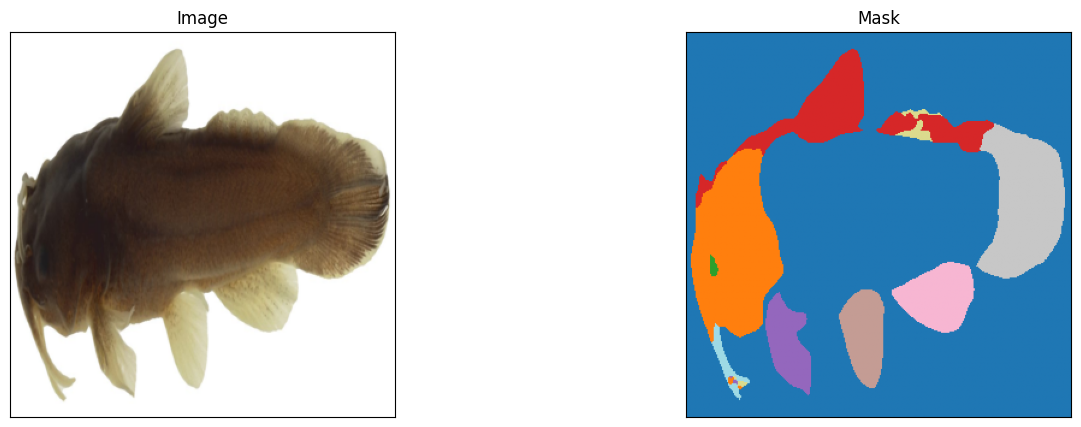

In [9]:
# Get a sample 
img, class_id, _ = train_dataset[0]
# Predict mask and compute descriptors
mask = predict_mask(model=segmentation_model, image_tensor=img, mean=model_mean, std=model_std)
features = extract_all_features(img, mask)
# Print outputs
print(f'original image size: {img.size}','mask shape:', mask.shape, 'class_ids:', np.unique(mask))
print('feature length:', len(features))
print(features)
visualize(image=img, mask=mask)

In [10]:
features = extract_combined_features(img, mask)
len(features)

233

original image size: <built-in method size of Tensor object at 0x7f170d7ad190> mask shape: (320, 320) class_ids: [0 1 2 3 4 5 6 7]
feature length: 1892
{'part1_area': np.float32(4064.0), 'part1_perimeter': np.float32(369.52185), 'part1_aspect_ratio': np.float32(2.0126722), 'part1_extent': np.float32(0.6377903), 'part1_solidity': np.float32(0.86504894), 'part1_eccentricity': np.float32(0.86783534), 'part1_orientation': np.float32(-0.099968605), 'part1_circularity': np.float32(0.37401006), 'part1_elongation': np.float32(0.5031481), 'part1_compactness': np.float32(2.673725), 'part1_sift_ds1': np.float32(23.846153), 'part1_sift_ds2': np.float32(17.0), 'part1_sift_ds3': np.float32(9.307693), 'part1_sift_ds4': np.float32(8.923077), 'part1_sift_ds5': np.float32(22.384615), 'part1_sift_ds6': np.float32(18.846153), 'part1_sift_ds7': np.float32(17.153847), 'part1_sift_ds8': np.float32(10.923077), 'part1_sift_ds9': np.float32(114.69231), 'part1_sift_ds10': np.float32(57.692307), 'part1_sift_ds11'

/tmp/ipykernel_1403146/2379468421.py:58: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np_image = np.array(image)


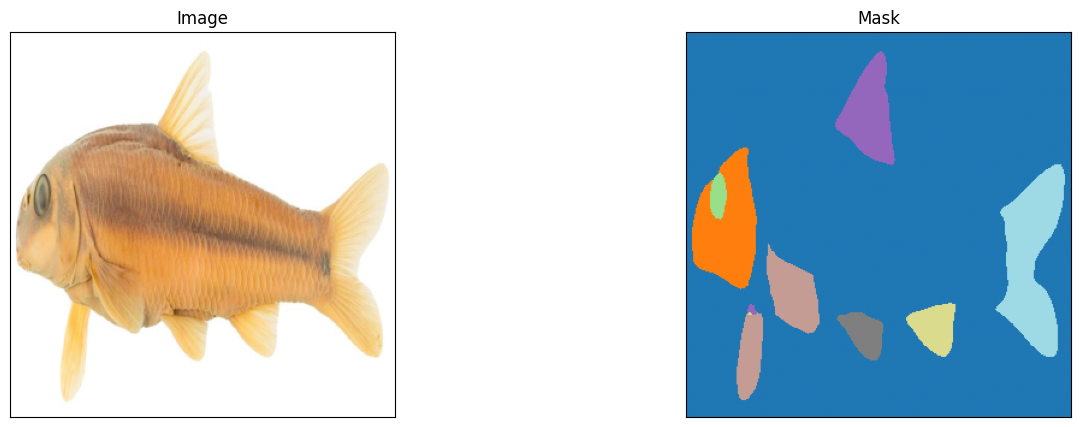

In [11]:
# Get a sample 
img, class_id, _ = train_dataset[2077]
# Predict mask and compute descriptors
mask = predict_mask(model=segmentation_model, image_tensor=img, mean=model_mean, std=model_std)
features = extract_all_features(img, mask)
# Print outputs
print(f'original image size: {img.size}','mask shape:', mask.shape, 'class_ids:', np.unique(mask))
print('feature length:', len(features))
print(features)
visualize(image=img, mask=mask)

In [ ]:
# Get a sample 
img, class_id, _ = train_dataset[22055]
# Predict mask and compute descriptors
mask = predict_mask(model=segmentation_model, image_tensor=img, mean=model_mean, std=model_std)
features = extract_all_features(img, mask)
# Print outputs
print(f'original image size: {img.size}','mask shape:', mask.shape, 'class_ids:', np.unique(mask))
print('feature length:', len(features))
print(features)
visualize(image=img, mask=mask)

In [12]:
# --- Replace NaNs within each species group ---
def fill_by_class_mean(df, class_col="species"):
    df = df.replace(0, np.nan)
    df = df.dropna(axis=1, how='all')
    df_numeric = df.select_dtypes(include=[np.number])
    # Fill NaNs in numeric columns using the class-wise mean
    df[df_numeric.columns] = df.groupby(class_col)[df_numeric.columns].transform(
        lambda x: x.fillna(x.mean())
    )
    # Step 2: fill any remaining NaNs globally (for columns that were all NaN in a class)
    df[df_numeric.columns] = df[df_numeric.columns].fillna(df[df_numeric.columns].mean())
    return df

In [13]:
def extract_features_for_dataset(dataset, output_csv):
    records = []
    print(f"Extracting shape features for {len(dataset)} images...")

    # i = 0
    for idx, (img, class_id, img_path) in enumerate(tqdm(dataset)):
        mask = predict_mask(model=segmentation_model, image_tensor=img, mean=model_mean, std=model_std)
        features = extract_all_features(img, mask)
        # img_path, _ = dataset.samples[idx]
        record = {"image": os.path.basename(img_path),
                  "class_id": class_id}
        record.update(features)
        records.append(record)

    df = pd.DataFrame(records)
    df.to_csv(output_csv, index=False)
    print(f"✅ Saved shape features to: {output_csv}")
    return df

In [14]:
os.makedirs(r"./shape_features_fishvista", exist_ok=True)

In [ ]:
%%time
output_csv = r"./shape_features_fishvista/fishvista_shape_features_train.csv"
df = extract_features_for_dataset(train_dataset, output_csv)
df

In [15]:
%%time
output_csv = r"./shape_features_fishvista/fishvista_shape_features_val_new.csv"
df = extract_features_for_dataset(val_dataset, output_csv)
df

Extracting shape features for 6779 images...


 30%|███       | 2051/6779 [49:41<1:27:00,  1.10s/it]/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/brisque/brisque.py:114: RuntimeWarning: invalid value encountered in scalar divide
  return (np.sum(np.abs(x)) / size) ** 2 / (np.sum(x ** 2) / size)
/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/brisque/brisque.py:124: RuntimeWarning: invalid value encountered in divide
  return squares_sum / ((filtered_values.shape))
/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/pypiqe/piqe.py:142: RuntimeWarning: invalid value encountered in divide
  ipImage = np.round(255 * (ipImage / np.max(ipImage)))
100%|██████████| 6779/6779 [2:31:24<00:00,  1.34s/it]  


✅ Saved shape features to: ./shape_features_fishvista/fishvista_shape_features_val_new.csv
CPU times: user 7h 27min 58s, sys: 33min 37s, total: 8h 1min 36s
Wall time: 2h 31min 46s


,image,class_id,part1_area,part1_perimeter,part1_aspect_ratio,part1_extent,part1_solidity,part1_eccentricity,part1_orientation,part1_circularity,...,part9_piqe,area_ratio_part1_to_part9,area_ratio_part2_to_part9,area_ratio_part3_to_part9,area_ratio_part4_to_part9,area_ratio_part5_to_part9,area_ratio_part6_to_part9,area_ratio_part7_to_part9,area_ratio_part9_to_total,area_ratio_part8_to_part9
0,INHS_FISH_22501.jpg,1106,4748.0,470.676178,2.269812,0.591725,0.826890,0.897721,0.021561,0.269325,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,INHS_FISH_59332.jpg,910,7754.0,484.558441,1.933036,0.588539,0.902257,0.855792,-0.188829,0.414995,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,60898_lat_FMNH_FZ_l.jpg,1151,4114.0,359.421356,2.043306,0.616884,0.856548,0.872058,-0.203424,0.400190,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,INHS_FISH_33052.jpg,277,9734.0,617.428528,2.025227,0.531158,0.808270,0.869591,-0.141502,0.320869,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,UWZM-F-0001159.JPG,910,6868.0,476.179749,1.605713,0.555933,0.862381,0.782400,-0.188812,0.380626,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6774,mb801162#0.jpg,894,3715.0,406.657898,2.442667,0.619786,0.823178,0.912360,0.185856,0.282300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6775,1911.6.1.100-101b_Eutropius ansorgii_v-S.jpg,1569,1376.0,399.320862,4.191826,0.208485,0.379586,0.971128,0.165835,0.108439,...,86.907181,91.73333,NaN,0.933333,12.466666,33.466663,6.466666,92.133324,0.004196,0.133333
6776,mb128835.jpeg,407,6213.0,507.872162,2.007891,0.578977,0.852848,0.867157,-0.139198,0.302693,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6777,mb124471.jpeg,1060,5353.0,518.451843,1.782534,0.472046,0.690442,0.827816,-0.096923,0.250259,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
%%time
output_csv = r"./shape_features_fishvista/fishvista_shape_features_test.csv"
df = extract_features_for_dataset(test_dataset, output_csv)
df